# Temas Tratados en el Trabajo Práctico 3

* Estrategias de búsqueda local.

* Algoritmos Evolutivos.

* Problemas de Satisfacción de Restricciones.

# Ejercicios Teóricos

1. ¿Qué mecanismo de detención presenta el algoritmo de Ascensión de Colinas? Describa el problema que puede presentar este mecanismo y cómo se llaman las áreas donde ocurren estos problemas.


2. Describa las distintas heurísticas que se emplean en un problema de Satisfacción de Restricciones.

3. Se desea colorear el rompecabezas mostrado en la imagen con 7 colores distintos de manera que ninguna pieza tenga el mismo color que sus vecinas. Realice en una tabla el proceso de una búsqueda con Comprobación hacia Adelante empleando una heurística del Valor más Restringido.

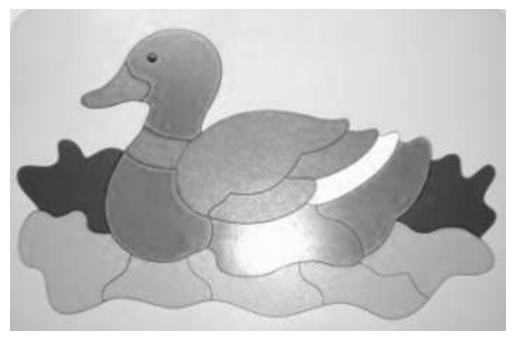

In [2]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1j94jFVxVG9y_ZnrMWOscQGb2MZ0Cdb3R"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

# Ejercicios de Implementación

4. Encuentre el máximo de la función $f(x) = \frac{\sin(x)}{x + 0.1}$ en $x \in [-10; -6]$ con un error menor a $0.1$ utilizando el algoritmo _hill climbing_.

5. Diseñe e implemente un algoritmo de Recocido Simulado para que juegue contra usted al Ta-te-ti. Varíe los valores de temperatura inicial entre partidas, ¿qué diferencia observa cuando la temperatura es más alta con respecto a cuando la temperatura es más baja?


6. Diseñe e implemente un algoritmo genético para cargar una grúa con $n=10\;cajas$ que puede soportar un peso máximo $C=1000\;kg$. Cada caja *j* tiene asociado un precio $p_j$ y un peso $w_j$ como se indica en la tabla de abajo, de manera que el algoritmo debe ser capaz de maximizar el precio sin superar el límite de carga.

<table><tr><td>Elemento ($j$)</td><td>1</td><td>2</td><td>3</td><td>4</td><td>5</td><td>6</td><td>7</td><td>8</td><td>9</td><td>10</td></tr>

<tr><td>Precio ($p_j$)</td><td>100</td><td>50</td><td>115</td><td>25</td><td>200</td><td>30</td><td>40</td><td>100</td><td>100</td><td>100</td></tr>

<tr><td>Peso ($w_j$)</td><td>300</td><td>200</td><td>450</td><td>145</td><td>664</td><td>90</td><td>150</td><td>355</td><td>401</td><td>395</td></tr></table><br>

        6.1 En primer lugar, es necesario representar qué cajas estarán cargadas en la grúa y cuáles no. Esta representación corresponde a un Individuo con el que trabajará el algoritmo.

        6.2 A continuación, genere una Población que contenga un número $N$ de individuos (se recomienda elegir un número par). Es necesario crear un control que verifique que ninguno de los individuos supere el peso límite.

        6.3 Cree ahora una función que permita evaluar la Idoneidad de cada individuo y seleccione $N/2$ parejas usando el método de la ruleta.

        6.4 Por último, Cruce las parejas elegidas, aplique un mecanismo de Mutación y verifique que los individuos de la nueva población no superen el límite de peso.

        6.5 Realice este proceso iterativamente hasta que se cumpla el mecanismo de detención de su elección y muestre el mejor individuo obtenido junto con el peso y el precio que alcanza.

### Prompt utilizado para el ejercio 6
Actúa como un experto en Inteligencia Artificial y Optimización. Necesito que diseñes e implementes en Python un Algoritmo Genético clásico paso a paso para resolver una variante del Problema de la Mochila (Knapsack Problem) aplicada a la carga de una grúa, cumpliendo estrictamente con las directrices teóricas e instrucciones del docente de la cátedra.

---

### 1. DATOS DEL PROBLEMA
* **Capacidad Máxima de Carga (C):** 1000 kg.
* **Número de Elementos (n):** 10 cajas disponibles.
* **Vectores de Datos (Listas en Python):**
  * ID de Cajas: `[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]`
  * Precios (p): `[100, 50, 115, 25, 200, 30, 40, 100, 100, 100]`
  * Pesos (w):   `[300, 200, 450, 145, 664, 90, 150, 355, 401, 395]`

---

### 2. REQUISITOS OBLIGATORIOS DE IMPLEMENTACIÓN

El código en Python debe ser completamente modular, estar ampliamente comentado y seguir paso a paso esta estructura:

#### A. Representación del Individuo
* Cada individuo (solución candidata) debe representarse como un **cromosoma o vector binario de longitud 10** (por ejemplo, `[1, 0, 1, 0...]`), donde un `1` en la posición `j` indica que la caja `j+1` está cargada en la grúa y un `0` indica que no lo está.

#### B. Población Inicial
* Inicializá una población de tamaño N (por ejemplo, N = 50 o 100, preferentemente par) con individuos aleatorios de 0s y 1s.
* **Control de Peso Inicial:** Cualquier individuo inicial que supere el peso permitido de 1000 kg debe ser descartado o reparado inmediatamente para asegurar que arrancamos con soluciones factibles.
* **Implementación desde cero:** El algoritmo debe ser programado en Python puro (apoyándote únicamente en Numpy para operaciones vectoriales). Queda totalmente prohibido el uso de bibliotecas preexistentes de algoritmos genéticos como `deap` o `scipy.optimize`.
#### C. Función de Idoneidad (Fitness) y Selección por Ruleta (Estocástica)
* **Fitness:** El valor de fitness de un cromosoma factible es la **suma de los precios** de los elementos cargados (`1`).
* **Selección por Ruleta:** Implementá el método de selección por ruleta de forma estocástica pura (no uses torneos). 
  1. Calculá la suma total de las aptitudes (puntos) de la población de la generación actual para definir el 100% de la ruleta.
  2. Normalizá el fitness de cada individuo dividiéndolo por esa suma para obtener su perfil de probabilidad acumulada.
  3. Seleccioná N/2 parejas de padres de manera independiente.
  4. **Restricción de Endogamia (Muy Importante):** Un padre **no puede cruzarse consigo mismo**. Si la ruleta selecciona el mismo individuo para ambos roles de la pareja, implementá el descarte del segundo: quitá al primer padre seleccionado de las probabilidades, normalizá los valores de los restantes, y volvé a tirar la ruleta (o realizá tiradas consecutivas hasta asegurar un segundo padre distinto).
#### D. Operadores Genéticos (Crossover y Mutación)
* **Cruce (Crossover):** Implementá un cruce clásico de **un punto** (Single-Point Crossover). La barrera o punto de corte se debe elegir de forma aleatoria por cada pareja en cada iteración.
* **Mutación (Bit-flip):** Implementá una probabilidad de mutación baja por gen (por ejemplo, entre 1% y 5%). Si ocurre la mutación, alterá el bit (0 pasa a 1, o 1 pasa a 0).
* **Tasa de mutación específica:** Definí la tasa de mutación como una variable paramétrica al inicio del script con un valor fijo del **5%** (`prob_mutacion = 0.05`). Esta probabilidad debe evaluarse de forma independiente para cada uno de los 10 genes del cromosoma.
#### E. Mecanismo de Reparación de Hijos Inválidos (Heurística del Profesor)
En lugar de descartar o re-mutar infinitamente a los hijos generados tras el cruce y la mutación que superen los 1000 kg de peso total, aplicá la siguiente heurística de reparación recomendada por la cátedra:
* Si el peso total de un nuevo descendiente supera los 1000 kg, el algoritmo debe **"apagar" secuencialmente los genes (cambiar de `1` a `0`)** uno a uno hasta que el peso total baje del límite permitido de 1000 kg.
* **Estrategia inteligente de apagado:** Para que la reparación sea óptima, programá que se apaguen primero las cajas activas que tengan la **peor relación precio/peso (p_j / w_j)** o, en su defecto, que se haga de manera aleatoria únicamente de entre las cajas que están cargadas (bits con valor 1).

#### F. Criterio de Parada e Iteración
* El algoritmo debe ejecutarse durante un espacio amplio (como mínimo **300 generaciones**) para dar margen a la exploración de soluciones.
* Alternativamente, añadí un criterio de parada cualitativo si el mejor valor de fitness no muestra mejoras (estancamiento) tras un número consecutivo de generaciones.
* **Visualización simplificada:** No agregues diagramas de dispersión ni gráficos de barras adicionales. Centrate únicamente en un único gráfico de convergencia lineal que sea limpio, profesional y fácil de interpretar.
---

### 3. FORMATO DE SALIDA Y VISUALIZACIÓN

El script final debe entregar:
1.	**Gráfico de Convergencia (Matplotlib):** Una gráfica que muestre en el eje X las generaciones (iteraciones) y en el eje Y el **mejor valor de fitness encontrado** en esa generación. Esto servirá para analizar cómo progresa la búsqueda y si se estanca ante diferentes tasas de mutación.
2.	* **Seguimiento generacional:** El gráfico de convergencia debe registrar y mostrar obligatoriamente el mejor valor de fitness (precio total acumulado) obtenido en **cada una** de las generaciones individuales, desde la 0 hasta la última, para visualizar con precisión la curva de aprendizaje y la velocidad de convergencia.
2. **Resultados en Consola:** Un informe claro que detalle la mejor solución encontrada al final del proceso:
   - Configuración final del vector binario (Cromosoma óptimo).
   - Qué cajas específicas seleccionó (número de cajas).
   - Peso total final (que no supere los 1000 kg).
   - Precio total máximo alcanzado.



In [ ]:
"""
Algoritmo Genético para el Problema de la Mochila (Knapsack Problem)
Aplicado a la carga de una grúa

Autor: Experto en IA y Optimización
Descripción: Implementación clásica paso a paso de un AG para resolver
una variante del problema de la mochila con capacidad de 1000 kg y 10 elementos.
"""

import numpy as np
import matplotlib.pyplot as plt
import random

# =============================================================================
# 1. DATOS DEL PROBLEMA
# =============================================================================
ID_CAJAS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
PRECIOS = [100, 50, 115, 25, 200, 30, 40, 100, 100, 100]
PESOS = [300, 200, 450, 145, 664, 90, 150, 355, 401, 395]
CAPACIDAD_MAXIMA = 1000
N_ELEMENTOS = len(ID_CAJAS)

# =============================================================================
# 2. PARÁMETROS DEL ALGORITMO GENÉTICO
# =============================================================================
TAMANO_POBLACION = 900  # Tamaño de la población (par)
PROB_MUTACION = 0.01   # 5% de probabilidad de mutación por gen
NUM_GENERACIONES = 900 # Número máximo de generaciones
CRITERIO_ESTANCAMIENTO = 600  # Generaciones sin mejora para detener

# =============================================================================
# 3. FUNCIONES AUXILIARES
# =============================================================================

def peso_total(cromosoma):
    """
    Calcula el peso total de un cromosoma (individuo)
    
    Args:
        cromosoma: Lista binaria de longitud N_ELEMENTOS
        
    Returns:
        float: Peso total de los elementos seleccionados
    """
    return sum(cromosoma[i] * PESOS[i] for i in range(N_ELEMENTOS))


def precio_total(cromosoma):
    """
    Calcula el precio total (fitness) de un cromosoma (individuo)
    
    Args:
        cromosoma: Lista binaria de longitud N_ELEMENTOS
        
    Returns:
        float: Precio total de los elementos seleccionados
    """
    return sum(cromosoma[i] * PRECIOS[i] for i in range(N_ELEMENTOS))


def es_factible(cromosoma):
    """
    Verifica si un cromosoma es factible (no supera la capacidad máxima)
    
    Args:
        cromosoma: Lista binaria de longitud N_ELEMENTOS
        
    Returns:
        bool: True si es factible, False en caso contrario
    """
    return peso_total(cromosoma) <= CAPACIDAD_MAXIMA


def generar_individuo_aleatorio():
    """
    Genera un individuo aleatorio factible
    
    Returns:
        list: Cromosoma binario factible
    """
    # Generar cromosoma aleatorio
    cromosoma = [random.randint(0, 1) for _ in range(N_ELEMENTOS)]
    
    # Reparar si es necesario (asegurar factibilidad)
    cromosoma = reparar_individuo(cromosoma)
    
    return cromosoma


def reparar_individuo(cromosoma):
    """
    Repara un individuo que supera el peso máximo aplicando la heurística
    de apagado secuencial de las cajas con peor relación precio/peso
    
    Args:
        cromosoma: Lista binaria de longitud N_ELEMENTOS
        
    Returns:
        list: Cromosoma reparado (factible)
    """
    # Verificar si el individuo ya es factible
    if peso_total(cromosoma) <= CAPACIDAD_MAXIMA:
        return cromosoma.copy()
    
    # Crear una copia del cromosoma para trabajar
    cromosoma_reparado = cromosoma.copy()
    
    # Obtener índices de los elementos activos (bits con valor 1)
    indices_activos = [i for i in range(N_ELEMENTOS) if cromosoma_reparado[i] == 1]
    
    # Calcular la relación precio/peso para cada elemento activo
    # y ordenarlos de menor a mayor relación (peores primero)
    relaciones = [(i, PRECIOS[i] / PESOS[i]) for i in indices_activos]
    relaciones.sort(key=lambda x: x[1])  # Orden ascendente (peor relación primero)
    
    # Apagar elementos secuencialmente hasta que sea factible
    for i, _ in relaciones:
        if peso_total(cromosoma_reparado) > CAPACIDAD_MAXIMA:
            cromosoma_reparado[i] = 0
        else:
            break
    
    return cromosoma_reparado


# =============================================================================
# 4. FUNCIONES DEL ALGORITMO GENÉTICO
# =============================================================================

def inicializar_poblacion(tamano):
    """
    Inicializa la población con individuos aleatorios factibles
    
    Args:
        tamano: Tamaño de la población
        
    Returns:
        list: Lista de cromosomas (población inicial)
    """
    poblacion = []
    while len(poblacion) < tamano:
        individuo = generar_individuo_aleatorio()
        poblacion.append(individuo)
    return poblacion


def calcular_fitness_poblacion(poblacion):
    """
    Calcula el fitness (precio total) de todos los individuos de la población
    
    Args:
        poblacion: Lista de cromosomas
        
    Returns:
        list: Lista de valores de fitness
    """
    return [precio_total(individuo) for individuo in poblacion]


def seleccion_ruleta(poblacion, fitness_values):
    """
    Implementa la selección por ruleta (estocástica pura)
    
    Args:
        poblacion: Lista de cromosomas
        fitness_values: Lista de valores de fitness correspondientes
        
    Returns:
        tuple: Dos padres seleccionados (diferentes entre sí)
    """
    # Calcular la suma total de fitness
    suma_fitness = sum(fitness_values)
    
    # Si la suma es 0, seleccionar aleatoriamente
    if suma_fitness == 0:
        idx1 = random.randint(0, len(poblacion) - 1)
        idx2 = random.randint(0, len(poblacion) - 1)
        while idx2 == idx1:
            idx2 = random.randint(0, len(poblacion) - 1)
        return poblacion[idx1], poblacion[idx2]
    
    # Calcular probabilidades normalizadas
    probabilidades = [f / suma_fitness for f in fitness_values]
    
    # Seleccionar el primer padre
    idx1 = np.random.choice(len(poblacion), p=probabilidades)
    padre1 = poblacion[idx1]
    
    # Seleccionar el segundo padre (diferente del primero)
    # Quitar al primer padre de las probabilidades
    indices_restantes = [i for i in range(len(poblacion)) if i != idx1]
    probabilidades_restantes = [probabilidades[i] for i in indices_restantes]
    
    # Normalizar las probabilidades restantes
    suma_restante = sum(probabilidades_restantes)
    if suma_restante == 0:
        # Si no hay probabilidad, seleccionar aleatoriamente
        idx2 = random.choice([i for i in range(len(poblacion)) if i != idx1])
    else:
        probabilidades_restantes = [p / suma_restante for p in probabilidades_restantes]
        idx2 = np.random.choice(indices_restantes, p=probabilidades_restantes)
    
    padre2 = poblacion[idx2]
    
    return padre1, padre2


def cruce_un_punto(padre1, padre2):
    """
    Implementa el cruce de un punto (Single-Point Crossover)
    
    Args:
        padre1: Primer cromosoma padre
        padre2: Segundo cromosoma padre
        
    Returns:
        tuple: Dos hijos resultantes del cruce
    """
    # Elegir punto de corte aleatorio (entre 1 y N_ELEMENTOS-1)
    punto_corte = random.randint(1, N_ELEMENTOS - 1)
    
    # Realizar el cruce
    hijo1 = padre1[:punto_corte] + padre2[punto_corte:]
    hijo2 = padre2[:punto_corte] + padre1[punto_corte:]
    
    return hijo1, hijo2


def mutacion_bit_flip(cromosoma, prob_mutacion):
    """
    Aplica la mutación bit-flip a un cromosoma
    
    Args:
        cromosoma: Lista binaria a mutar
        prob_mutacion: Probabilidad de mutación por gen
        
    Returns:
        list: Cromosoma mutado
    """
    cromosoma_mutado = cromosoma.copy()
    
    for i in range(N_ELEMENTOS):
        if random.random() < prob_mutacion:
            # Flip del bit (0->1, 1->0)
            cromosoma_mutado[i] = 1 - cromosoma_mutado[i]
    
    return cromosoma_mutado


def crear_nueva_generacion(poblacion):
    """
    Crea una nueva generación aplicando selección, cruce y mutación
    
    Args:
        poblacion: Población actual
        
    Returns:
        list: Nueva población generada
    """
    # Calcular fitness de la población actual
    fitness_values = calcular_fitness_poblacion(poblacion)
    
    # Nueva población (se generan TAMANO_POBLACION/2 pares)
    nueva_poblacion = []
    
    while len(nueva_poblacion) < TAMANO_POBLACION:
        # Seleccionar dos padres diferentes
        padre1, padre2 = seleccion_ruleta(poblacion, fitness_values)
        
        # Cruce de un punto
        hijo1, hijo2 = cruce_un_punto(padre1, padre2)
        
        # Mutación
        hijo1 = mutacion_bit_flip(hijo1, PROB_MUTACION)
        hijo2 = mutacion_bit_flip(hijo2, PROB_MUTACION)
        
        # Reparación de hijos inválidos
        hijo1 = reparar_individuo(hijo1)
        hijo2 = reparar_individuo(hijo2)
        
        # Agregar hijos a la nueva población
        nueva_poblacion.append(hijo1)
        nueva_poblacion.append(hijo2)
    
    return nueva_poblacion


# =============================================================================
# 5. FUNCIÓN PRINCIPAL DEL ALGORITMO GENÉTICO
# =============================================================================

def algoritmo_genetico():
    """
    Ejecuta el algoritmo genético completo
    
    Returns:
        tuple: (mejor_individuo, mejor_fitness, historial_fitness, historial_mejores)
    """
    print("=" * 60)
    print("ALGORITMO GENÉTICO PARA EL PROBLEMA DE LA MOCHILA")
    print("=" * 60)
    print(f"Capacidad máxima: {CAPACIDAD_MAXIMA} kg")
    print(f"Número de elementos: {N_ELEMENTOS}")
    print(f"Tamaño de población: {TAMANO_POBLACION}")
    print(f"Probabilidad de mutación: {PROB_MUTACION * 100}%")
    print(f"Número máximo de generaciones: {NUM_GENERACIONES}")
    print(f"Criterio de estancamiento: {CRITERIO_ESTANCAMIENTO} generaciones")
    print("-" * 60)
    
    # Inicializar población
    print("Inicializando población...")
    poblacion = inicializar_poblacion(TAMANO_POBLACION)
    
    # Verificar que todos los individuos sean factibles
    for i, individuo in enumerate(poblacion):
        if not es_factible(individuo):
            poblacion[i] = reparar_individuo(individuo)
    
    # Inicializar variables de seguimiento
    historial_fitness = []  # Guarda el mejor fitness de cada generación
    historial_promedios = []  # Guarda el fitness promedio de cada generación
    mejor_fitness_global = 0
    mejor_individuo_global = None
    generaciones_sin_mejora = 0
    
    print("Ejecutando evolución...")
    
    # Bucle principal de generaciones
    for generacion in range(NUM_GENERACIONES):
        # Calcular fitness de la población actual
        fitness_values = calcular_fitness_poblacion(poblacion)
        
        # Encontrar el mejor individuo de esta generación
        mejor_fitness_gen = max(fitness_values)
        idx_mejor = fitness_values.index(mejor_fitness_gen)
        mejor_individuo_gen = poblacion[idx_mejor]
        
        # Guardar en el historial
        historial_fitness.append(mejor_fitness_gen)
        historial_promedios.append(sum(fitness_values) / len(fitness_values))
        
        # Actualizar el mejor global
        if mejor_fitness_gen > mejor_fitness_global:
            mejor_fitness_global = mejor_fitness_gen
            mejor_individuo_global = mejor_individuo_gen.copy()
            generaciones_sin_mejora = 0
        else:
            generaciones_sin_mejora += 1
        
        # Mostrar progreso cada 10 generaciones
        if generacion % 10 == 0:
            print(f"Gen {generacion}: Mejor fitness = {mejor_fitness_gen}, "
                  f"Promedio = {historial_promedios[-1]:.2f}, "
                  f"Mejor global = {mejor_fitness_global}")
        
        # Verificar criterio de estancamiento
        if generaciones_sin_mejora >= CRITERIO_ESTANCAMIENTO:
            print(f"\n⚠️  Criterio de estancamiento alcanzado en la generación {generacion}")
            print(f"   No hubo mejora en las últimas {CRITERIO_ESTANCAMIENTO} generaciones")
            break
        
        # Crear nueva generación (excepto en la última iteración)
        if generacion < NUM_GENERACIONES - 1:
            poblacion = crear_nueva_generacion(poblacion)
    
    # Informe final
    print("\n" + "=" * 60)
    print("RESULTADOS FINALES")
    print("=" * 60)
    
    # Si no se encontró ningún individuo (caso extremo)
    if mejor_individuo_global is None:
        mejor_individuo_global = max(poblacion, key=precio_total)
        mejor_fitness_global = precio_total(mejor_individuo_global)
    
    # Calcular detalles de la mejor solución
    peso_final = peso_total(mejor_individuo_global)
    cajas_seleccionadas = [ID_CAJAS[i] for i in range(N_ELEMENTOS) 
                          if mejor_individuo_global[i] == 1]
    
    print(f"\n✅ Mejor solución encontrada:")
    print(f"   • Cromosoma óptimo: {mejor_individuo_global}")
    print(f"   • Cajas seleccionadas: {cajas_seleccionadas}")
    print(f"   • Cantidad de cajas: {len(cajas_seleccionadas)}")
    print(f"   • Peso total: {peso_final} kg (límite: {CAPACIDAD_MAXIMA} kg)")
    print(f"   • Precio total máximo: {mejor_fitness_global}")
    print(f"   • Generaciones ejecutadas: {len(historial_fitness)}")
    
    return mejor_individuo_global, mejor_fitness_global, historial_fitness, historial_promedios


# =============================================================================
# 6. VISUALIZACIÓN DE RESULTADOS
# =============================================================================

def graficar_convergencia(historial_fitness, historial_promedios, mejor_fitness):
    """
    Genera el gráfico de convergencia del algoritmo genético
    
    Args:
        historial_fitness: Lista con el mejor fitness por generación
        historial_promedios: Lista con el fitness promedio por generación
        mejor_fitness: Valor del mejor fitness encontrado
    """
    # Crear figura con estilo profesional
    plt.figure(figsize=(12, 7))
    
    # Configurar estilo
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Graficar el mejor fitness por generación
    generaciones = range(len(historial_fitness))
    plt.plot(generaciones, historial_fitness, 
             color='#2E86C1', linewidth=2.5, 
             label='Mejor fitness por generación')
    
    # Graficar el fitness promedio por generación
    plt.plot(generaciones, historial_promedios, 
             color='#E74C3C', linewidth=1.5, linestyle='--', alpha=0.7,
             label='Fitness promedio por generación')
    
    # Marcar el mejor fitness encontrado
    idx_mejor = historial_fitness.index(max(historial_fitness))
    plt.scatter(idx_mejor, max(historial_fitness), 
                color='#27AE60', s=150, zorder=5,
                label=f'Mejor solución: {max(historial_fitness)}')
    
    # Configurar etiquetas y título
    plt.xlabel('Generación', fontsize=12, fontweight='bold')
    plt.ylabel('Fitness (Precio Total)', fontsize=12, fontweight='bold')
    plt.title('Curva de Convergencia del Algoritmo Genético\n'
              'Problema de la Mochila - Carga de Grúa', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Añadir leyenda
    plt.legend(loc='lower right', fontsize=10, framealpha=0.95)
    
    # Añadir grid más fino
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Ajustar límites del eje Y para mejor visualización
    if historial_fitness:
        min_y = min(historial_promedios) * 0.8
        max_y = max(historial_fitness) * 1.05
        plt.ylim(min_y, max_y)
    
    # Añadir anotación con el mejor valor
    if historial_fitness:
        plt.annotate(f'Mejor fitness: {max(historial_fitness)}',
                     xy=(idx_mejor, max(historial_fitness)),
                     xytext=(idx_mejor + len(historial_fitness)*0.05, 
                             max(historial_fitness) * 0.95),
                     fontsize=10,
                     bbox=dict(boxstyle='round,pad=0.3', 
                              facecolor='#27AE60', 
                              edgecolor='none',
                              alpha=0.2))
    
    # Ajustar diseño
    plt.tight_layout()
    
    # Mostrar el gráfico
    plt.show()
    
    # Guardar el gráfico (opcional)
    # plt.savefig('convergencia_ag.png', dpi=300, bbox_inches='tight')


# =============================================================================
# 7. EJECUCIÓN DEL PROGRAMA PRINCIPAL
# =============================================================================

if __name__ == "__main__":
    # Fijar semilla para reproducibilidad (opcional)
    random.seed(42)
    np.random.seed(42)
    
    # Ejecutar el algoritmo genético
    mejor_individuo, mejor_fitness, historial_fitness, historial_promedios = algoritmo_genetico()
    
    # Generar el gráfico de convergencia
    print("\nGenerando gráfico de convergencia...")
    graficar_convergencia(historial_fitness, historial_promedios, mejor_fitness)
    
    print("\n" + "=" * 60)
    print("FIN DE LA EJECUCIÓN")
    print("=" * 60)


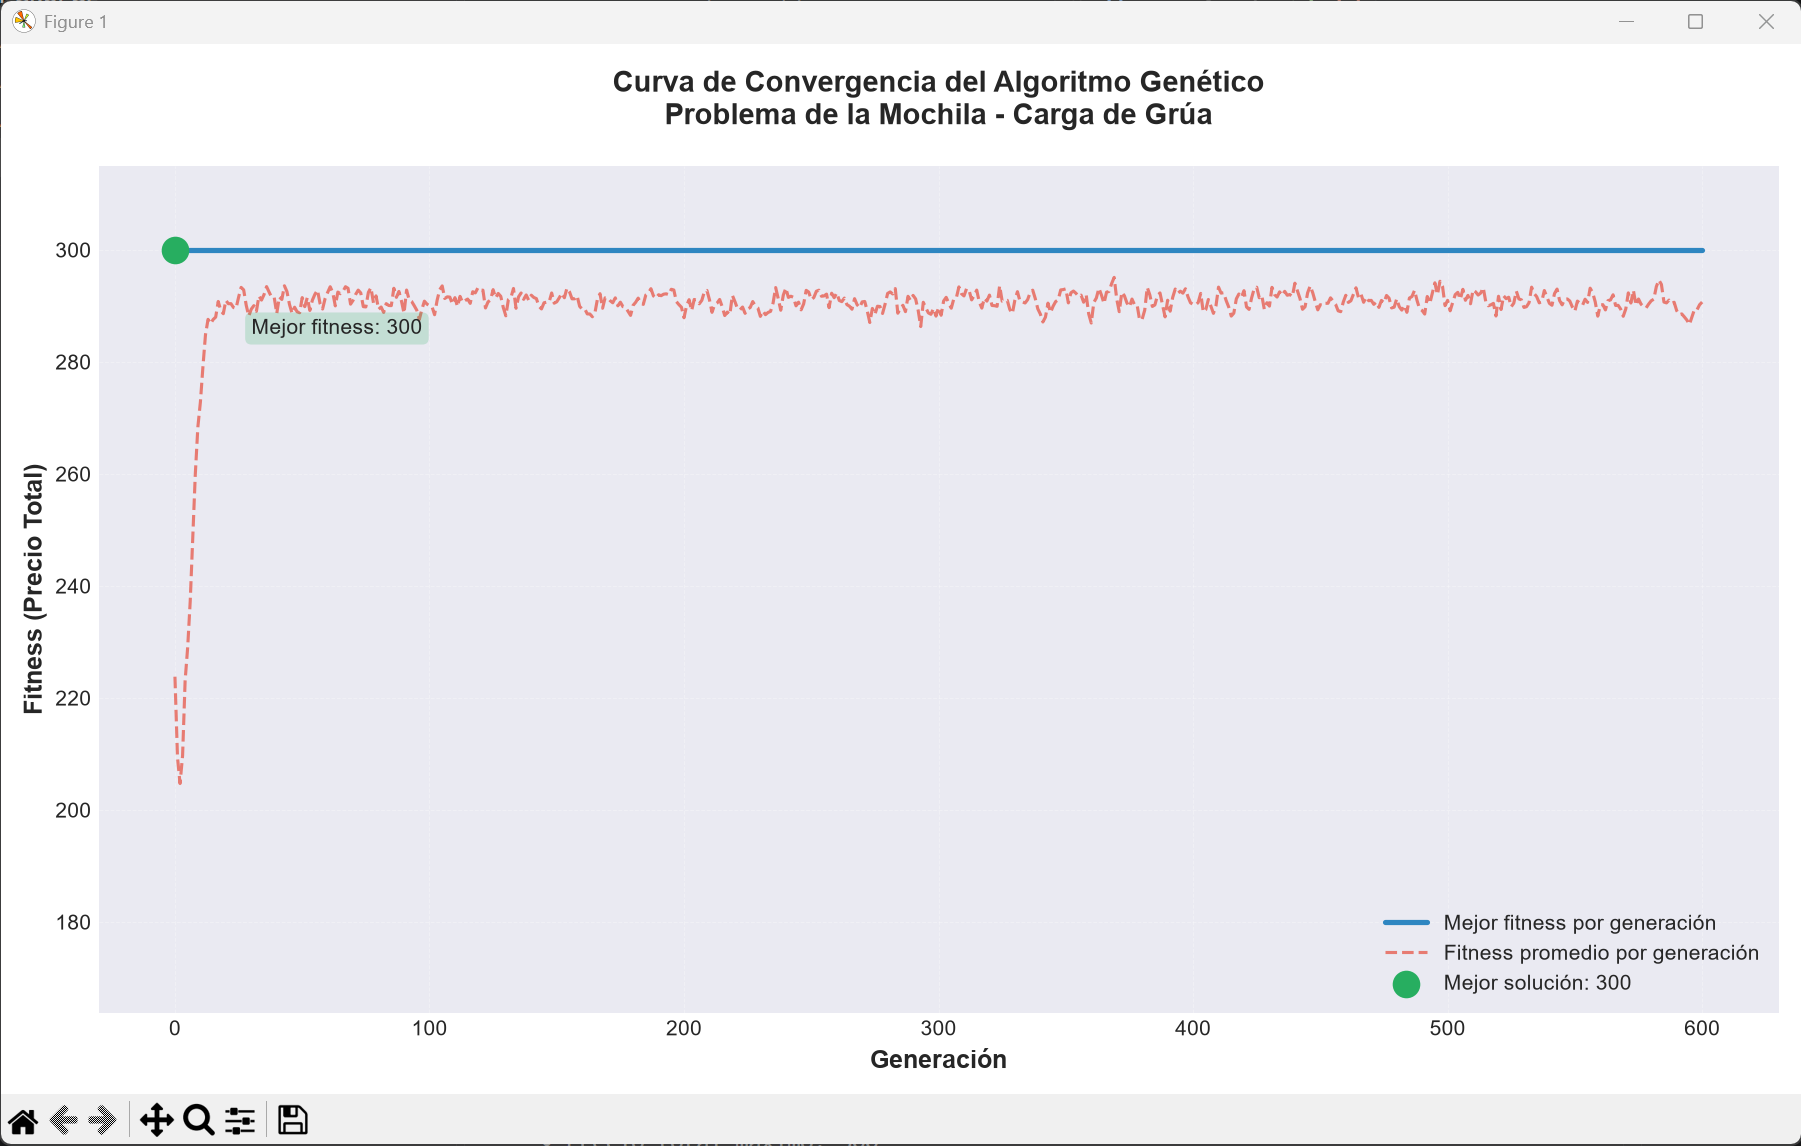

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)